 **Task 3**: **Exploratory Data Analysis (EDA)**

**Dataset: Netflix Dataset**

**Objective:**
**Identify trends and patterns using:**

* Summary statistics
* Correlation analysis
* Trend identification
* Graphs and visualizations

**Output:**
**Insights supported with graphs.**

***Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Load Dataset***

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


***Understand Dataset***

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


***Check missing values***

In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


***Basic Data Cleaning***

In [5]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [6]:
df.dropna(subset=['date_added'], inplace=True)

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

***Summary Statistics***

In [9]:
df.describe()

,date_added,release_year
count,8797,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.822191


***Count Movies vs TV Shows***

In [10]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


***Visualization 1***

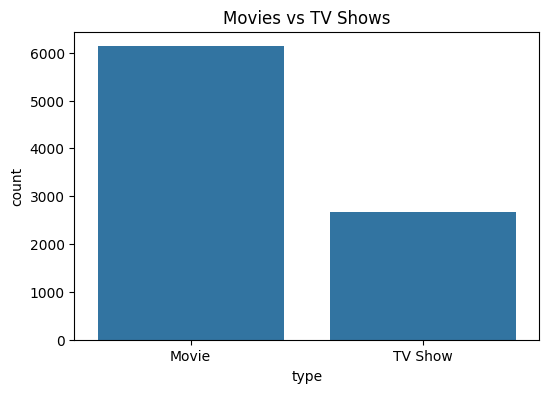

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

***Visualization 2***

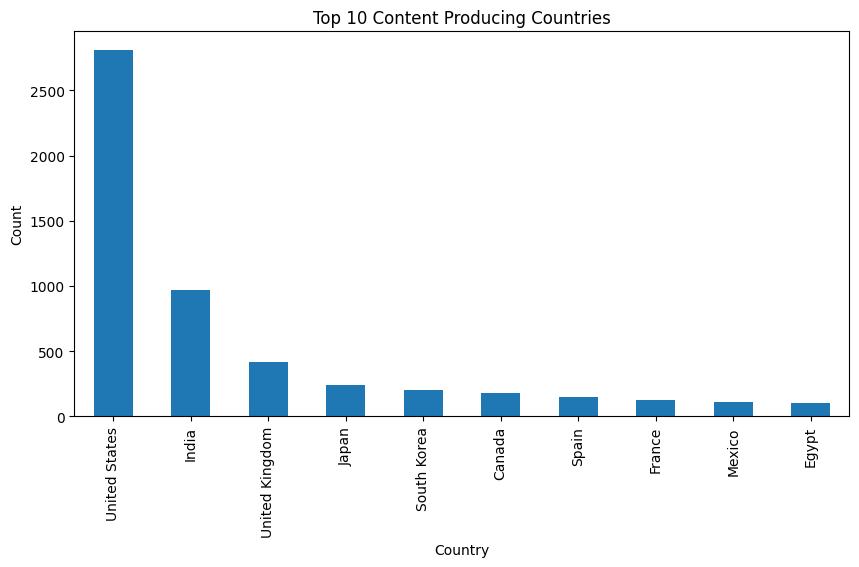

In [12]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

***Visualization 3***

In [13]:
df['year_added'] = df['date_added'].dt.year

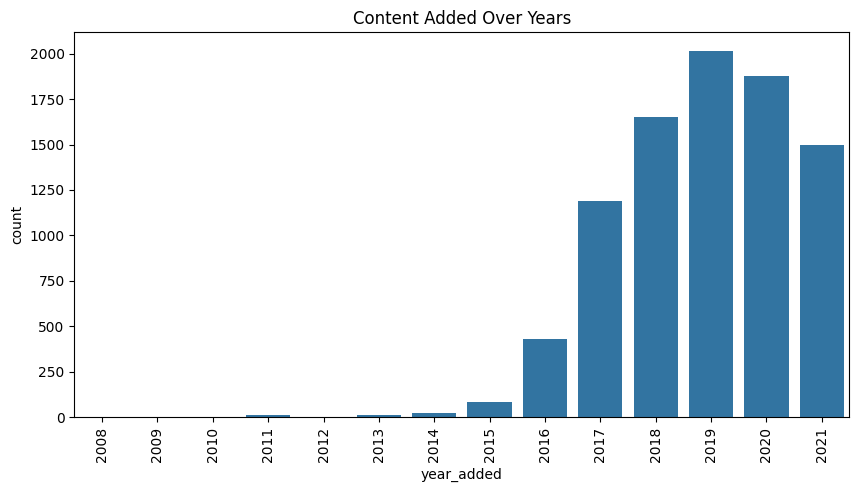

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='year_added', data=df)
plt.xticks(rotation=90)
plt.title("Content Added Over Years")
plt.show()

# Insight:

**Netflix content rapidly increased after 2015.**

**Streaming services discovered humanity enjoys watching murder documentaries while eating dinner. A species of contradictions**

***Correlation Analysis***

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

** Correlation matrix **

In [16]:
corr = numeric_df.corr()
corr

,release_year
release_year,1.0


***Heatmap***

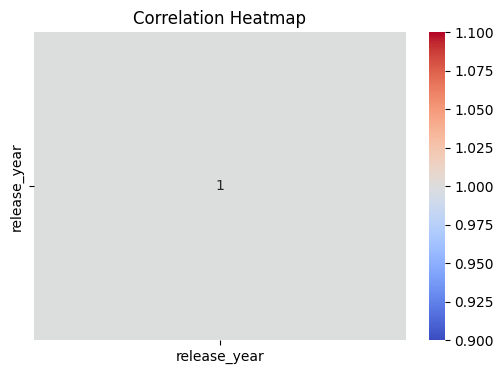

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

***Visualization 4***

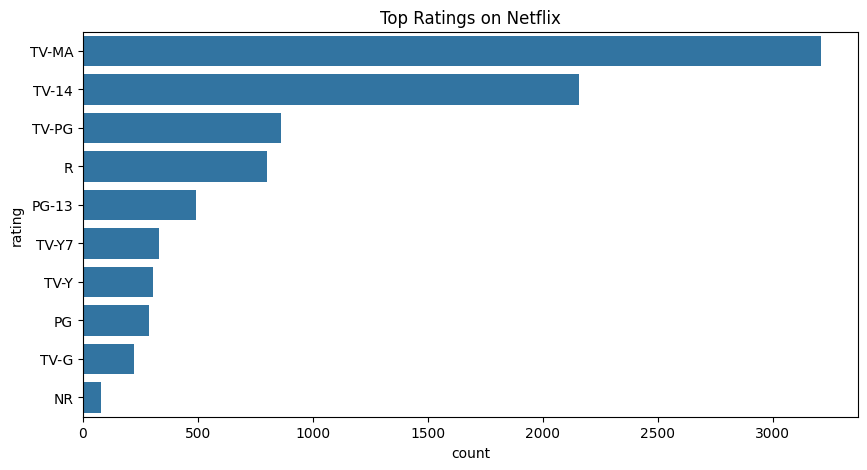

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df,
              order=df['rating'].value_counts().index[:10])
plt.title("Top Ratings on Netflix")
plt.show()

***Visualization 5***

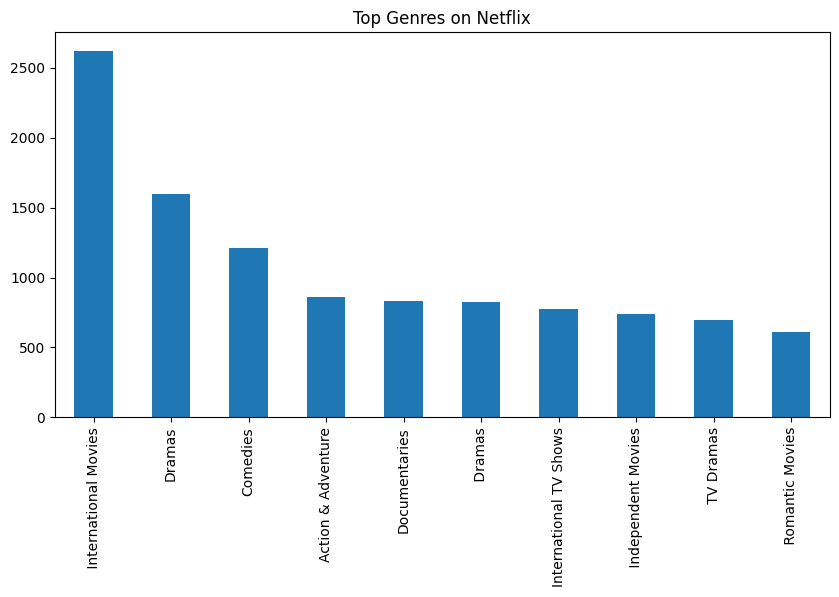

In [21]:
genres = df['listed_in'].str.split(',', expand=True).stack()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()

## Insights

1. Movies are more common than TV Shows on Netflix.
2. The United States produces the highest amount of content.
3. Netflix content increased significantly after 2015.
4. TV-MA is one of the most common ratings.
5. Drama and Comedy are among the top genres.

## Conclusion

* Exploratory Data Analysis was performed on the Netflix dataset.
* Several trends and patterns were identified using statistical analysis and visualizations.
* The analysis revealed growth in content production popular genres, and dominant content-producing countries.


In [22]:
df.to_csv("Netflix_EDA_Cleaned.csv", index=False)